In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [3]:
df = pd.DataFrame(lista_alumnos, columns=["nombre", "edad", "altura"])

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   nombre  21 non-null     str    
 1   edad    21 non-null     int64  
 2   altura  21 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 636.0 bytes


In [5]:
df.describe()

,edad,altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


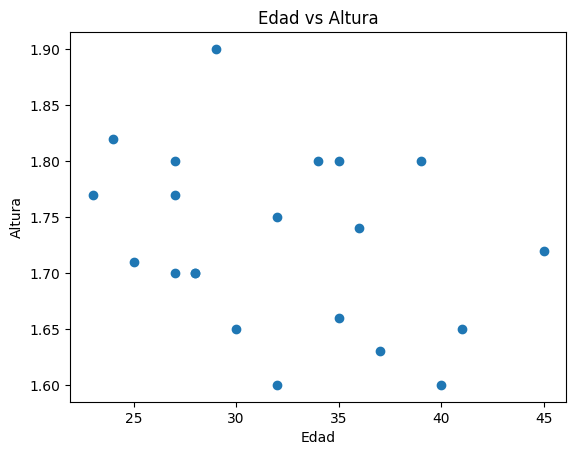

In [6]:
plt.scatter(df["edad"], df["altura"])
plt.xlabel("Edad")
plt.ylabel("Altura")
plt.title("Edad vs Altura")
plt.show()

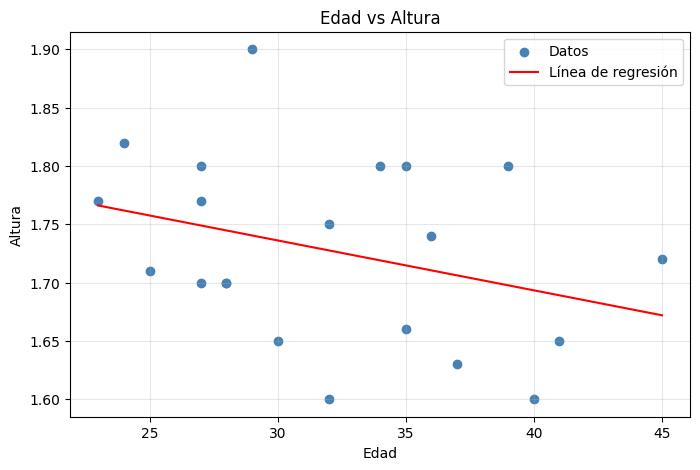

In [7]:
X = df[["edad"]]
y = df["altura"]

modelo = LinearRegression()
modelo.fit(X, y)

df_ordenado = df.sort_values("edad")
predicciones = modelo.predict(df_ordenado[["edad"]])

plt.figure(figsize=(8, 5))
plt.scatter(df["edad"], df["altura"], color="steelblue", label="Datos")
plt.plot(df_ordenado["edad"], predicciones, color="red", label="Línea de regresión")
plt.xlabel("Edad")
plt.ylabel("Altura")
plt.title("Edad vs Altura")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

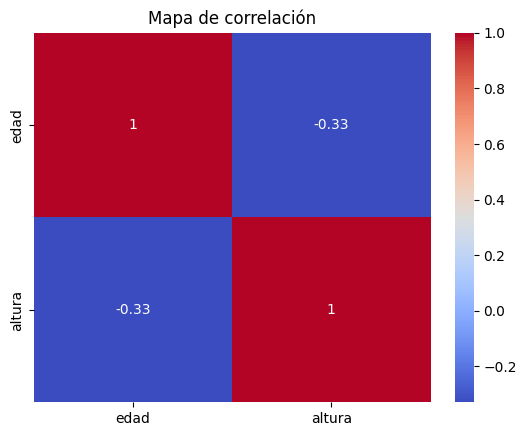

In [8]:
corr = df[["edad", "altura"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

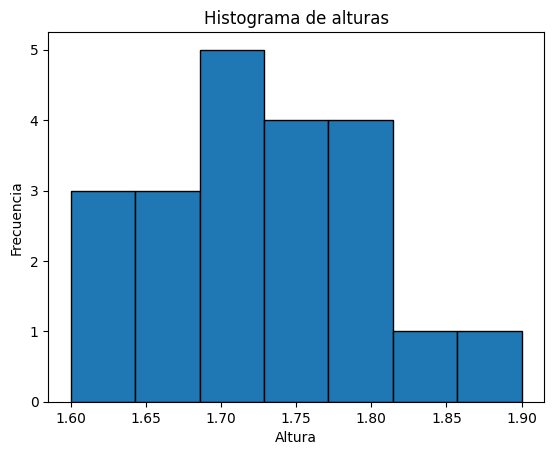

In [9]:
plt.hist(df["altura"], bins=7, edgecolor="black")
plt.xlabel("Altura")
plt.ylabel("Frecuencia")
plt.title("Histograma de alturas")
plt.show()

### Entrena un modelo de regresión lineal

In [10]:
df.columns

Index(['nombre', 'edad', 'altura'], dtype='str')

In [11]:
X = df[['edad']]
X

,edad
0,24
1,25
2,35
3,37
4,29
5,27
6,28
7,32
8,36
9,45


In [12]:
y = df['altura']
y

0     1.82
1     1.71
2     1.66
3     1.63
4     1.90
5     1.80
6     1.70
7     1.60
8     1.74
9     1.72
10    1.65
11    1.65
12    1.60
13    1.80
14    1.77
15    1.75
16    1.70
17    1.80
18    1.77
19    1.70
20    1.80
Name: altura, dtype: float64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Total features shape: (21, 1)
Train features shape: (16, 1)
Train target shape: (16,)
Test features shape: (5, 1)
Test target shape: (5,)


In [15]:
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
print(lr.intercept_)

1.858051298091961


In [19]:
X_train.columns

Index(['edad'], dtype='str')

In [20]:
print(lr.coef_)

[-0.00435721]


In [21]:
coeff_df = pd.DataFrame(lr.coef_,
                        X.columns,
                        columns=['Coefficient'])
coeff_df

,Coefficient
edad,-0.004357


In [22]:
lr.predict(([14], [25], [70]))

C:\Users\juan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.79705036, 1.74912105, 1.55304661])

y = a + b*x

altura = a + b*Edad

Altura = 1.86 - 0.004 * Edad

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [25]:
y_pred = lr.predict(X_test)
y_pred

array([1.75347826, 1.70990616, 1.71862058, 1.74912105, 1.70119174])

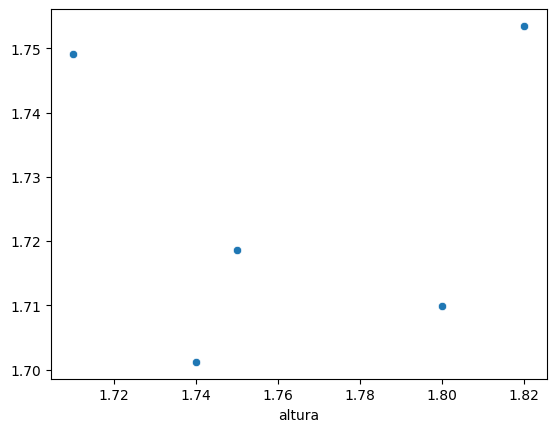

In [33]:
sns.scatterplot(x = y_test, y = y_pred);

In [47]:
y_test

0     1.82
17    1.80
15    1.75
1     1.71
8     1.74
Name: altura, dtype: float64

In [49]:
df_errores = pd.DataFrame(X_test)
df_errores['prediccion'] = y_pred
df_errores['valor_real'] = y_test
df_errores['error'] = abs(df_errores['valor_real'] - df_errores['prediccion'])
df_errores['error_cuadrado'] = df_errores['error']**2
df_errores

,edad,prediccion,valor_real,error,error_cuadrado
0,24,1.753478,1.82,0.066522,0.004425
17,34,1.709906,1.80,0.090094,0.008117
15,32,1.718621,1.75,0.031379,0.000985
1,25,1.749121,1.71,0.039121,0.001530
8,36,1.701192,1.74,0.038808,0.001506


In [57]:
print('MAE:', df_errores['error'].mean())
# (MAPE, no se) print('MAPE:', ((df_errores['error']/df_errores['prediccion'] + df_errores['error'])*100).mean())
print('MSE:', df_errores['error_cuadrado'].mean())
print('RMSE:', df_errores['error_cuadrado'].mean()**(1/2))

MAE: 0.05318486080700664
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326


In [46]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.05318486080700664
MAPE: 0.029943007687355166
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326
